In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('train.csv')

# Display the dimensions of the dataset
print(f"Dataset Shape: {df.shape}")

# Display dataset info (data types, non-null counts)
print("\n--- Data Info ---")
print(df.info())

# Display the first 5 rows
df.head()

Dataset Shape: (1460, 81)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Overall

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Calculate the correlation matrix for numerical columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# Get the top 10 features most correlated with SalePrice
top_correlations = correlation_matrix['SalePrice'].sort_values(ascending=False).head(11)

print("Top 10 features highly correlated with SalePrice:")
print(top_correlations)

Top 10 features highly correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [4]:
# Create a new dataframe with only the selected features and the target variable
selected_columns = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'SalePrice']
df_clean = df[selected_columns].copy()

# Check for any missing values in these specific columns
print("Missing values in our selected columns:")
print(df_clean.isnull().sum())

Missing values in our selected columns:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
SalePrice      0
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

# X contains the features (the 4 columns), y contains the target (SalePrice)
X = df_clean.drop('SalePrice', axis=1)
y = df_clean['SalePrice']

# Split the data: 80% for training (learning) and 20% for testing (exam)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape (Questions to study): {X_train.shape}")
print(f"Testing data shape (Exam questions): {X_test.shape}")

Training data shape (Questions to study): (1168, 4)
Testing data shape (Exam questions): (292, 4)


In [6]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data (1168 houses)
model.fit(X_train, y_train)

print("Model training is successfully completed!")

Model training is successfully completed!


In [7]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

# Show the model's predictions vs the actual true prices for the first 5 houses in the exam
comparison = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print(comparison.head())

      Actual Price  Predicted Price
892         154500    143522.478557
1105        325000    288596.453556
413         115000    136156.554463
522         159000    187027.687043
1036        315500    293501.054731


In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2) Score: {r2}")

Mean Squared Error (MSE): 1602914819.443908
Root Mean Squared Error (RMSE): 40036.4186640602
R-squared (R2) Score: 0.7910239048318479


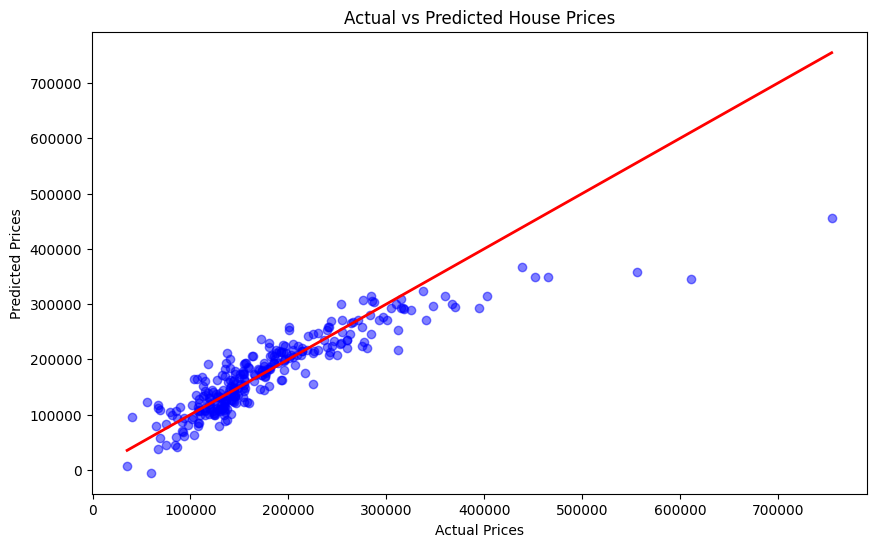

In [9]:
# Scatter plot: Actual prices vs. Predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [10]:
import pandas as pd

# Get the coefficients (weights) assigned by the model to each feature
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact on Price ($)': model.coef_
})

# Sort by highest impact
coefficients = coefficients.sort_values(by='Impact on Price ($)', ascending=False)
print(coefficients)

       Feature  Impact on Price ($)
0  OverallQual         23766.297562
2   GarageCars         19560.815807
1    GrLivArea            42.796305
3  TotalBsmtSF            28.403728


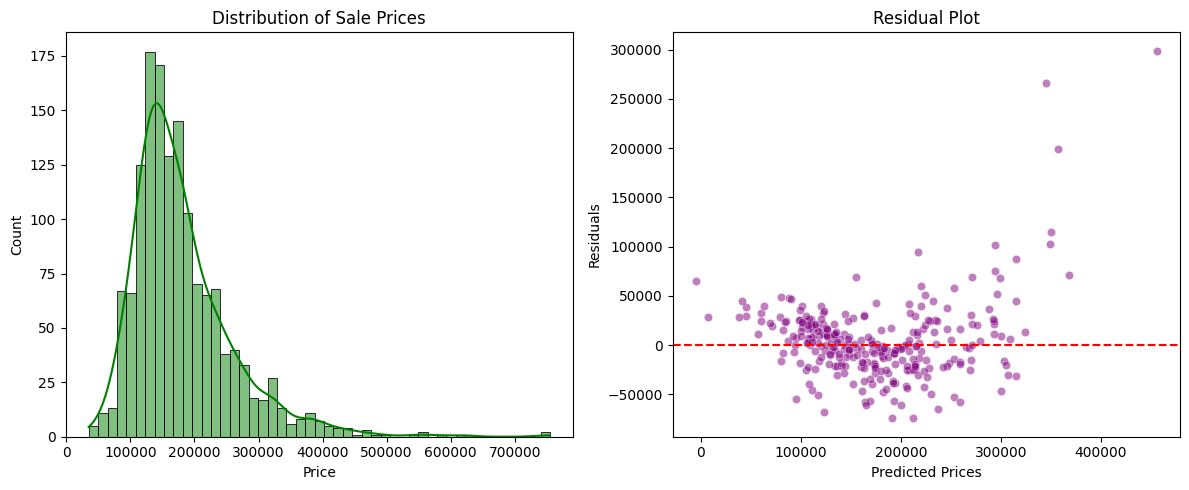

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 5))

# 1. Distribution of the target variable (SalePrice)
plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='green')
plt.title('Distribution of Sale Prices')
plt.xlabel('Price')

# 2. Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()